<a href="https://colab.research.google.com/github/johnjoseph004/AI-ML-internship/blob/main/day6_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import zipfile
import os
import cv2

zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 506


In [51]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

### Build the CNN Model

I will now define the architecture of our Convolutional Neural Network. The model will consist of several convolutional layers followed by max-pooling layers for feature extraction, a flatten layer to convert the 2D feature maps into a 1D vector, and dense layers for classification. Dropout layers will be included to prevent overfitting.

In [52]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

Now, I will compile the CNN model. For a binary classification task, I'll use the `adam` optimizer and `categorical_crossentropy` as the loss function (since `y_train_one_hot` is one-hot encoded). Accuracy will be used as the evaluation metric.

In [53]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Train the Model

Finally, I will train the CNN model using the prepared training data (`X_train`, `y_train_one_hot`) and validate it on the testing data (`X_test`, `y_test_one_hot`).

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7079 - loss: 0.5862 - val_accuracy: 0.7647 - val_loss: 0.4841
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7896 - loss: 0.4705 - val_accuracy: 0.8039 - val_loss: 0.4442
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8465 - loss: 0.4032 - val_accuracy: 0.8333 - val_loss: 0.3456
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8639 - loss: 0.3123 - val_accuracy: 0.8824 - val_loss: 0.2657
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8985 - loss: 0.2426 - val_accuracy: 0.8922 - val_loss: 0.2399
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9381 - loss: 0.1548 - val_accuracy: 0.9216 - val_loss: 0.1630
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9554 - loss: 0.1105 - val_accuracy: 0.9412 - val_loss: 0.1273
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9777 - loss: 0.0726 - val_accuracy: 0.9118 - val_loss:

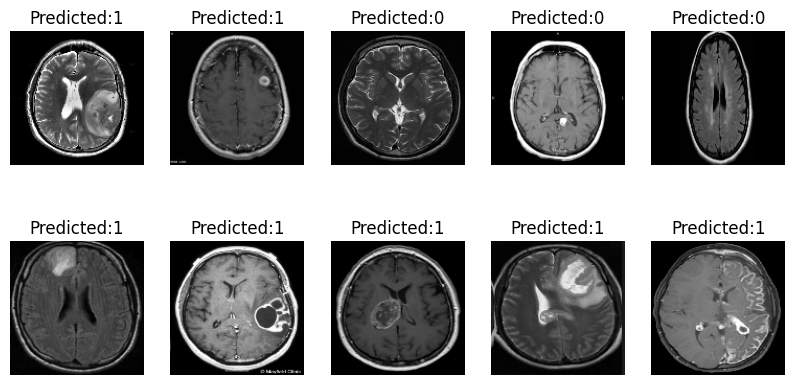

In [54]:
history = model.fit(X_train, y_train_one_hot,
                    epochs=10,
                    validation_data=(X_test, y_test_one_hot),
                    batch_size=32)
test_loss,test_acc=model.evaluate(X_test,y_test_one_hot)
print(f"\nTest accuracy:{test_acc:.4f}")
predictions=model.predict(X_test)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
for i in range(min(10, len(X_test))):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(IMG_SIZE,IMG_SIZE, 3) if X_test.shape[-1] == 3 else X_test[i].reshape(IMG_SIZE,IMG_SIZE),cmap='gray')
    plt.title(f"Predicted:{predictions[i].argmax()}")
    plt.axis('off')
plt.show()

### Test Model with User Input Image

Now, let's test our trained CNN model with a new image that you can upload. The process will involve:

1.  **Uploading an image**: You will be prompted to select an image file from your local machine.
2.  **Preprocessing the image**: The uploaded image will be resized and normalized to fit the model's input dimensions.
3.  **Making a prediction**: The preprocessed image will be fed to the model for classification.
4.  **Displaying the result**: The model's prediction (tumor or no tumor) will be shown.

In [60]:
from google.colab import files
import numpy as np

uploaded = files.upload()

for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    img_filename = fn

Saving brain tumour yes.jpeg to brain tumour yes (2).jpeg
User uploaded file "brain tumour yes (2).jpeg" with length 45485 bytes


Next, we need to preprocess the uploaded image to match the format our model expects. This includes resizing it to `IMG_SIZE` by `IMG_SIZE` pixels and normalizing its pixel values.

In [61]:
img = cv2.imread(img_filename)

if img is None:
    print(f"Error: Unable to load image {img_filename}. Please check the file path and format.")
else:
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img_normalized = img_resized / 255.0

    img_preprocessed = np.expand_dims(img_normalized, axis=0)

    print(f"Image '{img_filename}' preprocessed to shape: {img_preprocessed.shape}")

Image 'brain tumour yes (2).jpeg' preprocessed to shape: (1, 128, 128, 3)


Now, let's use the trained model to predict whether the uploaded image contains a tumor or not.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


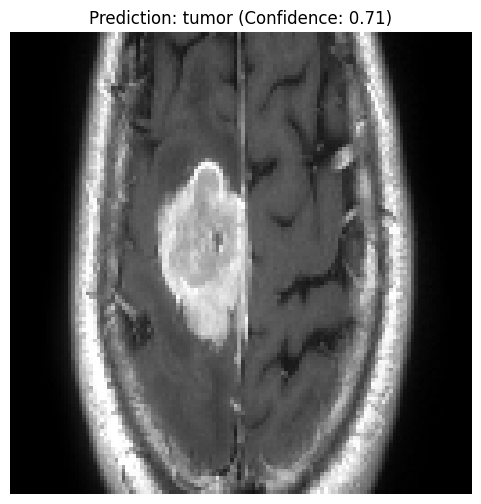

The model predicts: tumor with a confidence of 0.71


In [62]:
if 'img_preprocessed' in locals():
    prediction = model.predict(img_preprocessed)
    predicted_class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    class_labels = {0: 'no_tumor', 1: 'tumor'}
    predicted_label = class_labels[predicted_class_index]

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {predicted_label} (Confidence: {confidence:.2f})")
    plt.axis('off')
    plt.show()

    print(f"The model predicts: {predicted_label} with a confidence of {confidence:.2f}")
else:
    print("No image was successfully preprocessed for prediction.")